## Reproduce the results of Figure 8

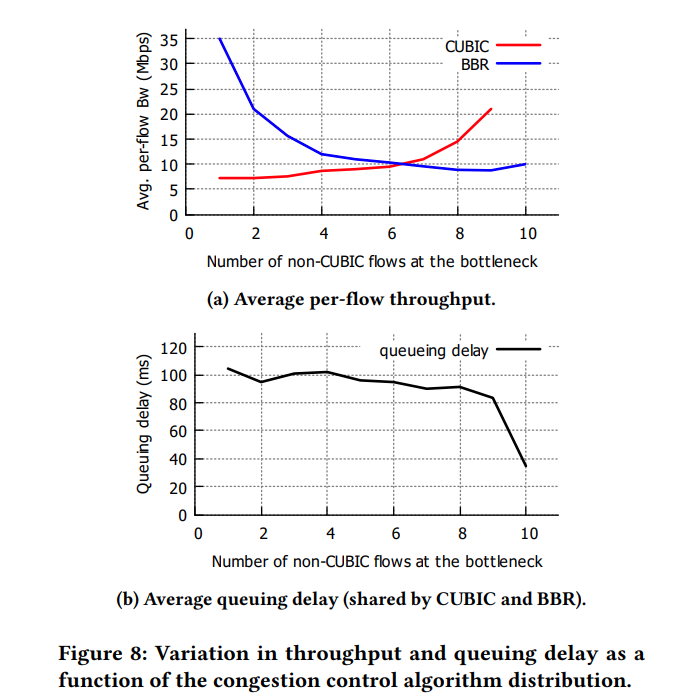

### Analyze data and generate plot

1
2
3
4
5
6
7
8
9


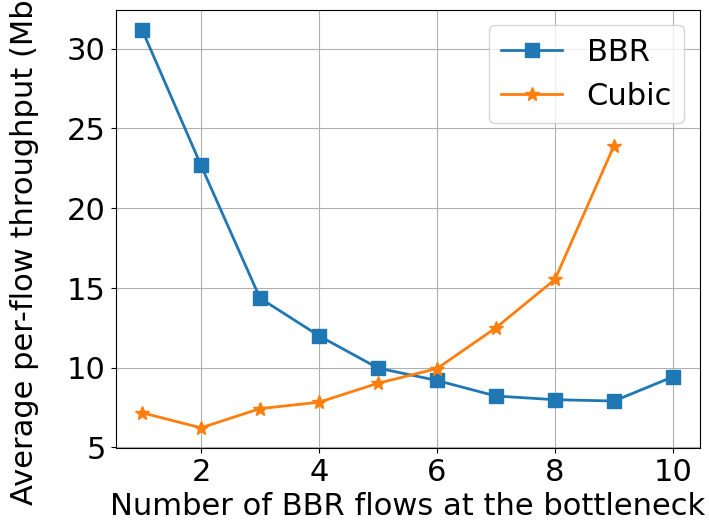

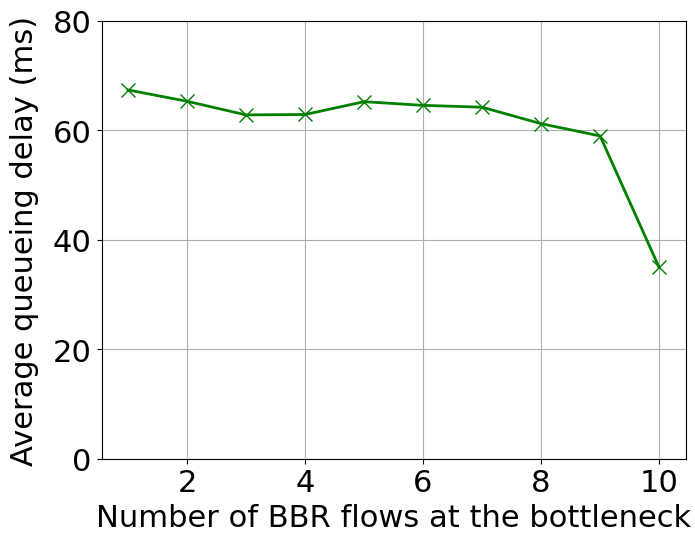

In [1]:
btl_capacity = 100 # mbit

import json

import numpy as np

import matplotlib.pyplot as plt

import pandas as pd

scenario ='100Mbps,40ms' # specify network scenario
#scenario ='nocap' # specify network scenario

per_flow_throughput_bbr = np.zeros(10)
per_flow_throughput_cubic = np.zeros(9)
average_queue_delay = np.zeros(10)


for i in range(1,10):
    # Load the JSON output file into a Python object
    with open("figure_8_results/{scenario}/bbr-result-{expid}.json".format(expid=i, scenario=scenario), "r") as f:
        iperf3_data = json.load(f)


    per_flow_throughput_bbr[i-1] = iperf3_data['end']['sum_received']['bits_per_second']/(1000000*i)
    #print(f"per_flow_throughput_bbr-{i}: {iperf3_data['end']['sum_received']['bits_per_second']/(1000000*i)} Mbps")
    
    with open("figure_8_results/{scenario}/cubic-result-{expid}.json".format(expid=i, scenario=scenario), "r") as f:
        iperf3_data = json.load(f)
    #print(f"per_flow_throughput_cubic-{i}: {iperf3_data['end']['sum_received']['bits_per_second']/(1000000*i)} Mbps")

    per_flow_throughput_cubic[i-1] = iperf3_data['end']['sum_received']['bits_per_second']/(1000000*(10-i))
    
    print(i)
    # Load the CSV file into a pandas DataFrame
    df = pd.read_csv("figure_8_results/{scenario}/queue-{expid}.csv".format(expid=i, scenario=scenario), header=None, names=["timestamp", "c2","backlog","c4"])

    average_queue_delay[i-1] = (df["backlog"].mean()*8)/(btl_capacity*1000)
    
with open("figure_8_results/{scenario}/bbr-result-{expid}.json".format(expid=10, scenario=scenario), "r") as f:
     iperf3_data = json.load(f)


per_flow_throughput_bbr[9] = iperf3_data['end']['sum_received']['bits_per_second']/(1000000*10)

df = pd.read_csv("figure_8_results/{scenario}/queue-{expid}.csv".format(expid=10, scenario=scenario), header=None, names=["timestamp", "c2","backlog","c4"])

average_queue_delay[9] = (df["backlog"].mean()*8)/(btl_capacity*1000)

plt.rcParams.update({'font.size': 22})

fontsize=22

linewidth=2.0

labelsize=22

markersize = 10


x1 = np.arange(1, 11)
x2 = np.arange(1, 10)
# Create the figure with a specific size
fig, ax = plt.subplots(figsize=(8,6))

# Plot the data
ax.plot(x1, per_flow_throughput_bbr, label='BBR', linewidth=linewidth, marker ='s', markersize=10)
ax.plot(x2, per_flow_throughput_cubic, label='Cubic', linewidth=linewidth, marker ='*', markersize=10)

# Set the font size of the tick labels
ax.tick_params(axis='both', which='major', labelsize=labelsize)

# Set the x-axis and y-axis labels
ax.set_xlabel('Number of BBR flows at the bottleneck', fontsize=fontsize)
ax.set_ylabel('Average per-flow throughput (Mbps)', fontsize=fontsize, labelpad=20)

# Leave a gap between the y-axis label and the tick labels
#ax.yaxis.set_label_coords(-0.1, 0.5, transform=ax.transAxes, labelpad=20)

# Add a legend
ax.legend(fontsize=fontsize)

# Add grid lines
ax.grid()

plt.subplots_adjust(left=0.17,bottom=0.15)
plt.savefig('figure_8a.svg')


# Create the figure with a specific size
fig, ax = plt.subplots(figsize=(8,6))

x1 = np.arange(1, 11)
ax.plot(x1, average_queue_delay, linewidth=linewidth, marker ='x', markersize=10, color = "green",  )
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.set_xlabel('Number of BBR flows at the bottleneck', fontsize=fontsize)
ax.set_ylabel('Average queueing delay (ms)', fontsize=fontsize,  labelpad=10)
plt.ylim(0, 80)
ax.grid()

plt.subplots_adjust(left=0.17,bottom=0.15)
plt.savefig('figure_8b.svg')